# 定理26　涅槃寂静定理 — 最小のトイ例（零苦集合と指数収束）

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> 定理26は四法印の4つ目（**涅槃寂静**）です。**仏教語の思想的な解釈と、形式化された数理結論は別物** として読んでください。
> 2次元の「動的寂静」の例（`theorem26_27_dynamic_quiescence`）は別の notebook にあります。この notebook は **最も単純な1次元の例** です。

## 1. 定理26は何を言っているのか

### 原文の主張

定理24は「空未満では、最良に生きても残りのしんどさ $J^*>0$」でした。定理26は、**空 $\top$ では $J^*=0$ になる状態が存在し、軌道はそこへ指数的に吸い込まれる** と述べます。

* **零苦集合（零残余苦価値集合）：**
$$
\mathcal N_\top(T)\;=\;\mathcal B_{\mathrm{alive}}\ \cap\ \bigl\{x\ \big|\ J^*_{\top,\rho}(x,T)=0\bigr\}.
$$
$\mathcal B_{\mathrm{alive}}$ は **生命活動が保たれる範囲**（入ったら出ない安全条件）。つまり「**生きたまま**、残りのしんどさ合計が **厳密にゼロ** の状態の集まり」です。
* **条件26-A：** $\mathcal N_\top$ は空でなく **前向き不変**（一度入れば、その後もずっと中に留まる）。
* **条件26-B：** 二次挟み込みの Lyapunov 関数 $W_\top$：$c_1\operatorname{dist}^2\le W_\top\le c_2\operatorname{dist}^2$、減衰 $D^+W_\top\le-\lambda W_\top$（$\lambda>0$）。
* **条件26-C：** 残余価値は距離で連続に抑えられる。

このとき（Grönwall の不等式）

$$
W_\top(x(t),t)\le W_\top(x(T),T)\,e^{-\lambda(t-T)}\ \Longrightarrow\ \operatorname{dist}\bigl(x(t),\mathcal N_\top(t)\bigr)\longrightarrow0,
$$

距離の評価は $\operatorname{dist}\le\sqrt{W_0/c_1}\,e^{-\lambda(t-T)/2}$。さらに $J^*\to0$（26.C）。
**永久的苦滅 $\Longleftrightarrow$ $a=\top$ かつ $x\in\mathcal N_\top$**（逆向きは定理24：空未満に永久零苦はない）。

### 原文の但し書き

* **寂静は物理的静止ではない。** 零苦集合 $\mathcal N_\top$ の中で運動し続けてよい（動的寂静。別の notebook で見ます）。
* **「有界化」と「滅尽」は別。** しきい値 $\theta>0$ の劣位集合 $\{V\le\theta\}$ に入っても得られるのは **苦の有界化** で、**滅尽ではありません**。厳密な滅尽には $V$ そのものがゼロの集合（$\mathcal N_\top$）が要ります。
* **空未満の層では 24-A により零苦集合は不成立**（26.3）。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 動き | $\dot x=-\lambda x$（$\lambda=1$） | `x = x0*exp(-lam*t)` |
| 最高抽象度の走行コスト $V_\top=3x^2$ | しんどさの点数 | `lambda x: 3*x**2` |
| 割引 $\rho=1$ | 遠い未来の重み | `rho` |
| $J^*_\top(x)=\int_0^\infty e^{-\rho t}\,3x^2e^{-2\lambda t}dt=\dfrac{3x^2}{\rho+2\lambda}=x^2$ | 残りのしんどさ合計 | `J_top`（数値積分） |
| 零苦集合 $\mathcal N_\top=\{0\}$ | $J^*_\top=0$ の状態 | `x0s[0] = 0` |
| 空未満の層 $a$ の走行コスト $\equiv1$ | $J^*_a=\int e^{-\rho t}dt=1/\rho>0$ | `J_sub` |
| $W=x^2$（$c_1=c_2=1$、$\lambda_W=2\lambda$） | Lyapunov 関数 | `W` |
| $\theta=0.75$ | 有界化のしきい値 | `theta` |

## 2. なぜこれが「定理26の例」と言えるのか

* **最高抽象度 $\top$：** 動きは決まった減衰 $\dot x=-x$。走行コスト $V_\top=3x^2$ を割引積分すると $J^*_\top(x_0)=x_0^2$。**$x_0=0$ なら $J^*=0$**、つまり零苦集合は $\mathcal N_\top=\{0\}$（空でなく、前向き不変：$0$ に居れば動かない）。
* **空未満の層 $a$：** 走行コストが **一定 $1$**（いつも何かしんどい）。割引積分は $1/\rho=1$。**どの $x_0$ でも $J^*_a=1>0$**（零苦不能）。定理24の状況です。
* **Lyapunov 関数：** $W=x^2$（$c_1=c_2=1$）。$x(t)=x_0e^{-t}$ なので $W=x_0^2e^{-2t}$、つまり $D^+W=-2W$（$\lambda_W=2\lambda=2$）。評価は **等号で成り立ちます**。
* **有界化との違い：** $V_\top\le\theta=0.75$ となる範囲（$3x^2\le0.75$、$|x|\le0.5$）の境界に居ても、$J^*>0$ のままです。

## 3. 計算

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

lam, rho = 1.0, 1.0
t = np.linspace(0, 40, 400001); dt = t[1] - t[0]
def J(x0, cost):                                   # 割引無限地平コスト(台形則)
    f = np.exp(-rho * t) * cost(x0 * np.exp(-lam * t))
    return ((f[1:] + f[:-1]) / 2).sum() * dt
x0s = np.array([0.0, 0.5, 1.0, 2.0])
J_top = np.array([J(x, lambda x: 3 * x**2) for x in x0s])
J_sub = np.array([J(x, lambda x: np.ones_like(x)) for x in x0s])

x = 2.0 * np.exp(-lam * t); W = x**2               # W=x², c1=c2=1, λ_W=2λ
bound = W[0] * np.exp(-2 * lam * t)                # (26.B) の指数評価(等号)
dist = np.abs(x); dist_bound = np.sqrt(W[0]) * np.exp(-2 * lam * t / 2)

# 有界化との違い: 「V≤θ に入った」だけでは J*>0 のまま
theta = 0.75; x_in = np.sqrt(theta / 3)            # 劣位集合 {3x²≤θ} の境界
J_in = J(x_in, lambda x: 3 * x**2)

* `J(x0, cost)` は、割引無限地平コスト $\int_0^{40}e^{-\rho t}\,\mathrm{cost}(x_0e^{-\lambda t})dt$ を台形則で近似します（40 秒で打ち切り。$e^{-40}$ は無視できる大きさ）。
* `J_top` は最高抽象度（$3x^2$）、`J_sub` は空未満（定数 $1$）の値。
* `J_in`：有界化の境界点 $x=\sqrt{\theta/3}=0.5$ での $J^*$。

## 4. 図を読む

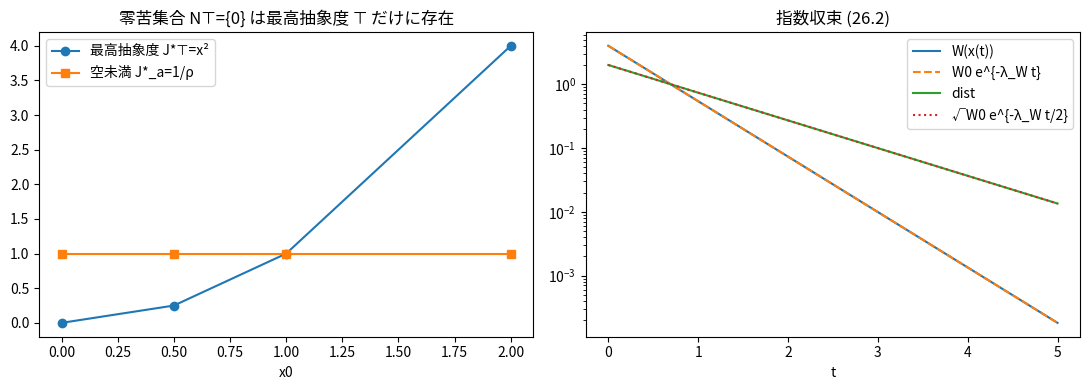

In [2]:
# %% 可視化
K = int(5 / dt)                                    # 0〜5 秒を表示
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x0s, J_top, "o-", label="最高抽象度 J*⊤=x²"); ax[0].plot(x0s, J_sub, "s-", label="空未満 J*_a=1/ρ")
ax[0].set_title("零苦集合 N⊤={0} は最高抽象度 ⊤ だけに存在"); ax[0].legend(); ax[0].set_xlabel("x0")
ax[1].semilogy(t[:K], W[:K], label="W(x(t))"); ax[1].semilogy(t[:K], bound[:K], "--", label="W0 e^{-λ_W t}")
ax[1].semilogy(t[:K], dist[:K], label="dist"); ax[1].semilogy(t[:K], dist_bound[:K], ":", label="√W0 e^{-λ_W t/2}"); ax[1].legend(); ax[1].set_xlabel("t"); ax[1].set_title("指数収束 (26.2)")
plt.tight_layout(); plt.show()

### 左：零苦集合は最高抽象度だけに存在する

横軸が初期位置 $x_0$、縦軸が $J^*$。
* **青（最高抽象度 $J^*_\top=x_0^2$）：** $x_0=0,\,0.5,\,1,\,2$ で $0,\,0.25,\,1,\,4$。**$x_0=0$ で $0$ に落ちます。** ここが零苦集合 $\mathcal N_\top=\{0\}$ です。
* **橙（空未満 $J^*_a=1/\rho=1$）：** **どの $x_0$ でも $1$ の水平線**。**$0$ にはなりません。** 定理24（空未満に永久零苦はない）と、定理26の対比です。
* 2本は $x_0=1$ で交わります（$J^*_\top=1$）。これは **グラフの交点にすぎず**、抽象度の高い・低いの優劣とは関係ありません。**肝心なのは $x_0=0$ で青だけが $0$ に届く** ことです。

### 右：指数収束（縦軸は対数）

$x_0=2$ の軌道で、$W(x(t))=x(t)^2$、$\operatorname{dist}(x(t),\mathcal N_\top)=|x(t)|$ を描いています。
* **青（$W$）と橙の破線（$W_0e^{-\lambda_Wt}$）：** **完全に重なる** 直線。$t=0$ の $4$ から $t=5$ の約 $1.8\times10^{-4}$ まで、傾き $-2$（$e^{-2t}$）。(26.B) の評価が **等号** で成り立っています。
* **緑（dist）と赤の点線（$\sqrt{W_0}\,e^{-\lambda_Wt/2}$）：** こちらも重なり、傾き $-1$（$e^{-t}$）。$t=0$ の $2$ から $t=5$ の約 $0.013$。距離の評価 $\operatorname{dist}\le\sqrt{W_0/c_1}\,e^{-\lambda_Wt/2}$ です。
* **距離は $W$ よりゆっくり減ります**（$W$ は距離の2乗だから、距離の指数は半分）。

## 5. 数値確認

In [3]:
# %% 数値確認
print("J*⊤ =", np.round(J_top, 4), " J*_a =", np.round(J_sub, 4), " θ境界でも J* =", round(J_in, 4))
assert np.allclose(J_top, x0s**2, atol=1e-3) and J_top[0] == 0
assert np.allclose(J_sub, 1 / rho, atol=1e-3)               # 空未満は常に正
assert np.all(W <= bound * (1 + 1e-9)) and np.all(dist <= dist_bound * (1 + 1e-9))
assert J_in > 0.2                                           # 有界化(苦が残る) ≠ 滅尽

J*⊤ = [0.   0.25 1.   4.  ]  J*_a = [1. 1. 1. 1.]  θ境界でも J* = 0.25


出力：「$J^*_\top=[0,\,0.25,\,1,\,4]$、$J^*_a=[1,1,1,1]$、有界化の境界点でも $J^*=0.25$」。
`assert` は、(i) $J^*_\top=x_0^2$ かつ $x_0=0$ で $0$、(ii) $J^*_a=1/\rho$（常に正）、(iii) $W$・$\operatorname{dist}$ が指数評価の内側、(iv) 有界化の境界点でも $J^*>0.2$（苦が残る）、を確かめます。

**(iv) の意味：** $\theta=0.75$ の劣位集合 $\{V_\top\le\theta\}=\{|x|\le0.5\}$ に **入っているだけでは**、$J^*=0.25>0$ で苦の合計が残っています。**苦が有界になる（有界化）のと、苦が消える（滅尽）のは別** です。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **何を「吹き消す」のか。** 涅槃の語源は「吹き消すこと」です。原文は、消えるのは **評価関数 $V$（いのちのエンジン）ではなく、残りのしんどさ合計 $J^*$** だと読みます。もし涅槃を「$V$ の値がなくなること」と読むと、生きたままの涅槃（即身成仏）は数学的に不可能になってしまう、と原文は述べます。
  この notebook でも、**$V_\top=3x^2$ は $x\neq0$ で正のまま** で、消えているのは $x=0$ における $J^*$ だけです。
* **有界化は滅尽ではない。** 原文は、$\Omega_\theta=\{V\le\theta\}$（$\theta>0$）は「苦の有界化」で、厳密な滅尽には $\Omega_0=\mathcal N_\top$ が要る、と区別します。(iv) の数値がそれです。
* **空未満では零苦集合は不成立（定理24）。** 橙の水平線。「永久的苦滅 $\Leftrightarrow$ 空、かつ $\mathcal N_\top$ の中」という同値の、逆向きの側です。
* **このトイの限界。** 動きが $\dot x=-x$ と決まっており、**選べる制御がありません**。生命維持の範囲 $\mathcal B_{\mathrm{alive}}$ も明示していません。涅槃の「生きたまま」「動き続けられる」という側面は、次の（輪の）例で扱います。

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem26_ValueZeroSet.lean`（既存 `Theorem24_26_Model.lean` と同一パラメータ）。

| | 内容 | 状態 |
| --- | --- | --- |
| 最適値と零苦集合 | $J^*=x^2$、零苦集合 $\{0\}$、空未満は $J^*=1$ | 証明済 |
| (26.2) の指数評価 | $W\le W_0e^{-\lambda_Wt}$、距離の評価 | 証明済 |
| 有界化 $\neq$ 滅尽 | 境界点でも $J^*>0$ | 証明済 |
| 数値積分の値（台形則） | 数値のみ | 未証明 |

* **制御空間は単点の特殊モデル** です（最適性は自明）。一般の制御・一般の $\mathcal B_{\mathrm{alive}}$ の定理26を証明したわけではありません。
* 空未満の層は「走行コストが定数 $1$」という玩具で、原文の抽象度の層構造そのものではありません。